# init

In [ ]:
import h5py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

from scipy.stats import spearmanr
from scipy.interpolate import make_smoothing_spline

from scipy.spatial import KDTree

from matplotlib.colors import to_rgba

import astropy.units as u

from astropy.cosmology import LambdaCDM

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

%matplotlib inline
from typing import Dict, Any
import matplotlib as mpl
# --- Global default: annotate in axes-fraction coordinates ---

cosmo = LambdaCDM(67.777, 0.307, 0.693)
class RuntimeConfig:

    ConfigDict = Dict[str, Dict[str, Any]]

    default_frame_color = (0.0, 0.0, 0.0, 0.8)
    default_config_dict = {
        # text
        'font': {'family': 'serif', 'weight': 'normal', 'size': 20, },
        'mathtext': {'fontset': 'cm', 'default': 'it', },

        # figure
        'figure': {
            'figsize': (8, 6),
        },
        # subplot
        'figure.subplot': {
            'wspace': 0.25, 'hspace': 0.25,
        },

        # axes frame
        'axes': {
            'labelsize': 16, 'labelweight': 'normal',
            'linewidth': 1,
            'edgecolor': default_frame_color,
            'edgecolor': default_frame_color,
            'grid': True,
        },
        'xtick': {
            'color': default_frame_color,
            'labelsize': 13, 'direction': 'in', 'top': True,
        },
        'xtick.major': {'width': 1.8, 'size': 9, },
        'xtick.minor': {'width': 1, 'size': 4, 'visible': True },
        'ytick': {'color': default_frame_color,
                  'labelsize': 13, 'direction': 'in', 'right': True},
        'ytick.major': {'width': 1.8, 'size': 9, },
        'ytick.minor': {'width': 1, 'size': 4, 'visible': True },
        'grid': {
            'color': 'gray', 'alpha': 0.5,
            'linestyle': (0, (1.6, 1.6)), 'linewidth': 0.8,
        },
        'patch': {'edgecolor': default_frame_color, },

        # plot artists
        'lines': {'linewidth': 2.5},
        'errorbar': {
            'capsize': 4,
        },
        'legend': {
            'numpoints': 2, 'scatterpoints': 3, 'markerscale': 1.0,
            'fontsize': 20, 'title_fontsize': 22,

            'loc': 'best',
            'handlelength': 2.0, 'handleheight': 0.5,
            'labelspacing': 0.1, 'handletextpad': 0.5,
            'borderpad': 0.25,
            'borderaxespad': 0.8, 'columnspacing': 1.0,

            'shadow': False, 'labelcolor': None,
            'frameon': False, 'framealpha': 0.8,
        },
    }

    def __init__(self, config_dict: ConfigDict = None) -> None:
        self.config_dict = RuntimeConfig.default_config_dict.copy()
        self.update(config_dict)

    def update(self, config_dict: ConfigDict = None):
        '''
        @config_dict: e.g.,
        {
            'axes': {'fontsize': 16, },
            'lines': {'linewidth': 2.5, },
        }
        '''
        if config_dict is not None:
            self.config_dict.update(config_dict)

    def set_global(self):
        for k, detail in self.config_dict.items():
            mpl.rc(k, **detail)


RuntimeConfig().set_global()

In [158]:
def calc_rmax_vmax(mhalo, rhalo, conc):
    def f(x):
        return np.log(1 + x) - x / (1 + x)
    rmax = 2.163 * (10**rhalo / 10**conc)
    vvir = np.sqrt(const.G * 10**mhalo / 10**rhalo * u.Msun / u.kpc).to(u.km / u.s).value
    vmax = vvir * np.sqrt(0.2163 * 10**conc / f(10**conc))
    return np.log10(rmax), np.log10(vmax)

def std_trim(x, n=3, return_mean=False):
    x_tmp = x.copy()
    while 1:
        mask_outerlier = np.abs(x_tmp - np.mean(x_tmp)) > n * np.std(x_tmp)
        if np.count_nonzero(mask_outerlier) > 0:
            x_tmp = x_tmp[~mask_outerlier]
        else:
            break
    if return_mean:
        return np.mean(x_tmp), np.std(x_tmp)
    else:
        return np.std(x_tmp)

def density_kd(data, npt=10):
    from scipy.spatial import KDTree
    from sklearn import preprocessing
    dim = data.shape[1]
    scaler = preprocessing.StandardScaler().fit(data)
    data = scaler.transform(data)
    d = KDTree(data).query(data, npt)[0][:, -1]
    density = np.log10(1 / d**dim / len(data))
    print("Density quantile:", np.quantile(density, np.linspace(0, 1, 3)))
    return density

def binned_statistic_overlap(x, y, xmids, delta, cnt_min=20, func=np.nanmean, bts=False):
    res = []
    for xmid in xmids:
        mask = np.abs(x - xmid) < delta / 2
        if np.count_nonzero(mask) < cnt_min:
            res.append(np.nan)
        else:
            res.append(func(y[mask]))
    res = np.array(res)

    if bts:
        res_list = []
        for i in range(30):
            ids = np.random.choice(np.arange(len(x)), len(x))
            res_list.append(binned_statistic_overlap(x[ids], y[ids], xmids, delta, cnt_min=cnt_min, func=func, bts=False))
        err = np.nanstd(res_list, axis=0)
        return res, err

    else:
        return res

def binned_spearman_overlap(x, y1, y2, xmids, delta, cnt_min=20, bts=False):
    res = []
    mask = np.isfinite(x * y1 * y2)
    x = x[mask]
    y1 = y1[mask]
    y2 = y2[mask]
    for xmid in xmids:
        mask = np.abs(x - xmid) < delta / 2
        if np.count_nonzero(mask) < cnt_min:
            res.append(np.nan)
        else:
            res.append(spearmanr(y1[mask], y2[mask])[0])

    res = np.array(res)
    if bts:
        res_list = []
        for i in range(100):
            ids = np.random.choice(np.arange(len(x)), len(x))
            res_list.append(binned_spearman_overlap(x[ids], y1[ids], y2[ids], xmids, delta, cnt_min=cnt_min, bts=False))
        err = np.nanstd(res_list, axis=0)
        return res, err

    else:
        return res

def smooth(xs, ys, lam=0.01):
    mask = np.isfinite(xs * ys)
    x_new = np.linspace(xs[mask][0], xs[mask][-1], 1000)
    y_new = make_smoothing_spline(xs[mask], ys[mask], lam=lam)(x_new)
    return x_new, y_new

def calc_vmax(mhalo, rhalo, conc):
    vvir = np.sqrt(10**mhalo / 10**rhalo)
    f = np.sqrt(0.216 * conc / (np.log(1 + conc) - conc / (1 + conc)))
    return f * vvir

def median_smooth(x, y, v, k, rmax=0.1, func=np.nanmedian):
    tree = KDTree(np.column_stack([x, y]))
    dists, ids = tree.query(np.column_stack([x, y]), k)
    vs = np.where(dists > rmax, np.nan, v[ids])
    return func(vs, 1)

def calc_rank(x, y, bins):
    rs = -np.ones(len(x))
    for l, u in zip(bins[:-1], bins[1:]):
        mask = (x >= l) & (x < u)
        size = np.count_nonzero(mask)
        r_tmp = np.arange(size).astype("double")
        y_tmp = y[mask].copy()
        r_tmp[np.argsort(y_tmp)] = np.arange(size) / size
        rs[mask] = r_tmp
    return rs

def calc_residual(x, y, x_edges):
    d = np.zeros(len(y))
    for xl, xu in zip(x_edges[:-1], x_edges[1:]):
        mask = (x >= xl) & (x < xu)
        med = np.median(y[mask])
        d[mask] = y[mask] - med
    return d

def calc_residual_2d(x1, x2, y, x1_edges, x2_edges, reserve_x=False):
    d = np.zeros(len(y))
    for x1l, x1u in zip(x1_edges[:-1], x1_edges[1:]):
        mask_x1 = (x1 >= x1l) & (x1 < x1u)
        y_med = np.median(y[mask_x1]) if reserve_x else 0
        for x2l, x2u in zip(x2_edges[:-1], x2_edges[1:]):
            mask = mask_x1 & ((x2 >= x2l) & (x2 < x2u))
            med = np.median(y[mask])
            d[mask] = y[mask] - med + y_med
    return d

# Dependence on dynamical friction

In [15]:
from halotools.empirical_models import halo_mass_to_halo_radius

base_dir = '/cosma5/data/durham/dc-hick2/Tau0_Investigation/Galform_Out_Default/L800/lc16.newmg/'
zero_dir = '/cosma5/data/durham/dc-hick2/Tau0_Investigation/Galform_Out_0tau0/L800/lc16.newmg/'
inf_dir = '/cosma5/data/durham/dc-hick2/Tau0_Investigation/Galform_Out_1e6tau0/L800/lc16.newmg/'

def load_gals(file, snap, ivols=None):
    gals = []
    ivols = np.arange(10) if ivols is None else ivols
    for ivol in ivols:
        gal = pd.DataFrame()
        with h5py.File(file % (snap, ivol), 'r') as f:
            logzsolar = np.log10(0.017)
            logh = np.log10(0.7)
            g = f['Output001']
            if ivol == 0:
                print(g.keys())
            mask = (g['mhhalo'][()] > 1e11)
            gal["snap"] = (g['SubhaloSnapNum'][()])[mask]
            gal["igrp"] = ((g['mhhalo'][()] * g['vhhalo'][()]).astype(int))[mask]
            gal['is_central'] = g['is_central'][()][mask]
            gal['xgal'] = g['xgal'][()][mask]
            gal['ygal'] = g['ygal'][()][mask]
            gal['zgal'] = g['zgal'][()][mask]
            gal["mstar"] = (np.log10(g['mstars_bulge'][()] + g['mstars_disk'][()] + 1e-3))[mask] - logh
            gal["mbh"] = (np.log10(g['M_SMBH'][()] + 1e-3))[mask] - logh
            gal["mhalo"] = (np.log10(g['mhhalo'][()] + 1e-3))[mask] - logh
        gals.append(gal)
    gals = pd.concat(gals)
    ngrp = len(np.unique(gals['igrp'].values))
    map_igrp = dict(zip(np.unique(gals['igrp'].values), np.arange(ngrp)))
    gals['igrp'] = np.array([map_igrp[i] for i in gals['igrp'].values])

    cen = gals[gals['is_central'] == 1]
    pos_cen = np.zeros((len(cen), 3))
    pos_cen[cen['igrp'].values, 0] = cen['xgal'].values
    pos_cen[cen['igrp'].values, 1] = cen['ygal'].values
    pos_cen[cen['igrp'].values, 2] = cen['zgal'].values

    dx = gals['xgal'].values - pos_cen[gals['igrp'].values, 0]
    dy = gals['ygal'].values - pos_cen[gals['igrp'].values, 1]
    dz = gals['zgal'].values - pos_cen[gals['igrp'].values, 2]

    L = 542.16
    dx = np.where(dx > L / 2, dx - L, dx)
    dx = np.where(dx < - L / 2, dx + L, dx)
    dy = np.where(dy > L / 2, dy - L, dy)
    dy = np.where(dy < - L / 2, dy + L, dy)
    dz = np.where(dz > L / 2, dz - L, dz)
    dz = np.where(dz < - L / 2, dz + L, dz)
    dr = np.sqrt(dx * dx + dy * dy + dz * dz)
    gals['dr'] = dr
    gals['rhalo'] = halo_mass_to_halo_radius(10**gals['mhalo'], cosmo, 0, "200c")
    gals['dr_norm'] = gals['dr']/ gals['rhalo']
    gals = gals[gals['dr_norm'] < 1]
    return gals


In [54]:
snap = 207
ivol = 9
with h5py.File((base_dir + 'iz%d/ivol%d/galaxies.hdf5') % (snap, ivol), 'r') as f:
    g = f['Output001']
    print(g.keys())
    print(g['Trees'].keys())
    x = g['Trees/jtree'][()]
    y = g['index'][()]
    z = g['mhhalo'][()]
    print(np.max(g['mhhalo'][()]))

<KeysViewHDF5 ['Bands', 'GalaxyMergerOn', 'Lines', 'M_SMBH', 'Molecular Lines', 'ParticleID', 'SMBH_Mdot_hh', 'SMBH_Mdot_stb', 'SMBH_Spin', 'SMBH_tacc_stb', 'SubhaloID', 'SubhaloIndex', 'SubhaloSnapNum', 'Trees', 'achalo', 'aform', 'angmom_disk', 'angmom_dm', 'burst_mode', 'cold_metal', 'halo_r_virial', 'hierarchy_level', 'hot_metal', 'ident_next_output', 'ihalof', 'ihhalo', 'index', 'is_central', 'mburst', 'mchalo', 'mcold', 'mcold_atom', 'mcold_atom_bulge', 'mcold_burst', 'mcold_cooling', 'mcold_major', 'mcold_minor', 'mcold_mol', 'mcold_mol_bulge', 'mcold_recycle', 'metals_burst', 'mhalo', 'mhhalo', 'mhhalo_before_conservation', 'mhot', 'mstardot', 'mstardot_average', 'mstardot_burst', 'mstars_allburst', 'mstars_bulge', 'mstars_burst', 'mstars_disk', 'mstars_instability', 'rbulge', 'rcomb', 'rdisk', 'redshift', 'spin', 'star_metal_bulge', 'star_metal_disk', 'strc', 'subhalo_spin_x', 'subhalo_spin_y', 'subhalo_spin_z', 'tburst', 'tsfburst', 'tsink', 'type', 'vbulge', 'vchalo', 'vdisk

In [265]:
gals_base = load_gals(base_dir + 'iz%d/ivol%d/galaxies.hdf5', 271)
gals_zero = load_gals(zero_dir + 'iz%d/ivol%d/galaxies.hdf5', 271)
gals_inf = load_gals(inf_dir + 'iz%d/ivol%d/galaxies.hdf5', 271)
len(np.unique(gals_base['igrp'])), np.count_nonzero(gals_base['is_central'] == 1)

(56011, 56011)

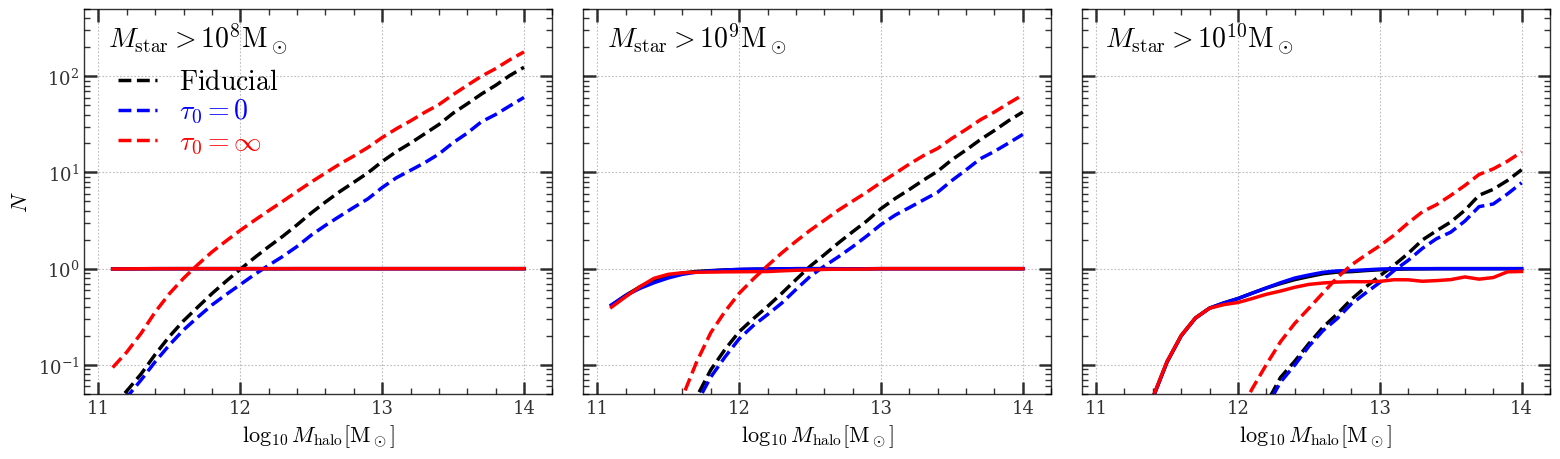

In [266]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), squeeze=False)
colors = 'k b r'.split()
mhalo_bins = np.linspace(10, 14, 41)
labels = [r'$\rm Fiducial$', r'$\tau_0=0$', r'$\tau_0=\infty$']
for igal, gal in enumerate([gals_base, gals_zero, gals_inf]):
    mstar = (gal['mstar'].values)
    mhalo = (gal['mhalo'].values)
    ifcen = (gal['is_central'].values == 1)
    ncen_unmask = binned_statistic_overlap(mhalo, ifcen, mhalo_bins, 0.2, func=np.sum)
    for imstarlim, mstarlim in enumerate([8, 9, 10]):
        ax = axes[0, imstarlim]
        mask_mstar = gal['mstar'].values > mstarlim
        
        ncen_mask = binned_statistic_overlap(mhalo[mask_mstar], ifcen[mask_mstar], mhalo_bins, 0.2, func=np.sum)
        hod_cen = ncen_mask / ncen_unmask
        ax.plot(mhalo_bins, hod_cen, color=colors[igal])
        
        nsat_mask = binned_statistic_overlap(mhalo[mask_mstar], ~ifcen[mask_mstar], mhalo_bins, 0.2, func=np.sum)
        hod_sat = nsat_mask / ncen_unmask
        ax.plot(mhalo_bins, hod_sat, color=colors[igal], ls='--', label=labels[igal])
        if igal == 0:
            ax.annotate(r"$M_{\rm star}>10^{%.0f}{\rm M_\odot}$" % mstarlim, (0.05, 0.9), xycoords="axes fraction", fontsize=20)

axes[0, 0].legend(loc=(0.04, 0.6), labelcolor=colors, fontsize=20)
for ax in fig.get_axes():
    ax.set_yscale('log')
    ax.axis([10.9, 14.2, 5e-2, 5e2])
    ax.set_xticks([11, 12, 13, 14])
    ax.set_xlabel(r"$\log_{10}M_{\rm halo}[{\rm M_\odot}]$")
    ax.set_ylabel(r"$N$")
    ax.label_outer()
fig.tight_layout()
# fig.savefig('./result/galform_dynfric/hod.pdf')

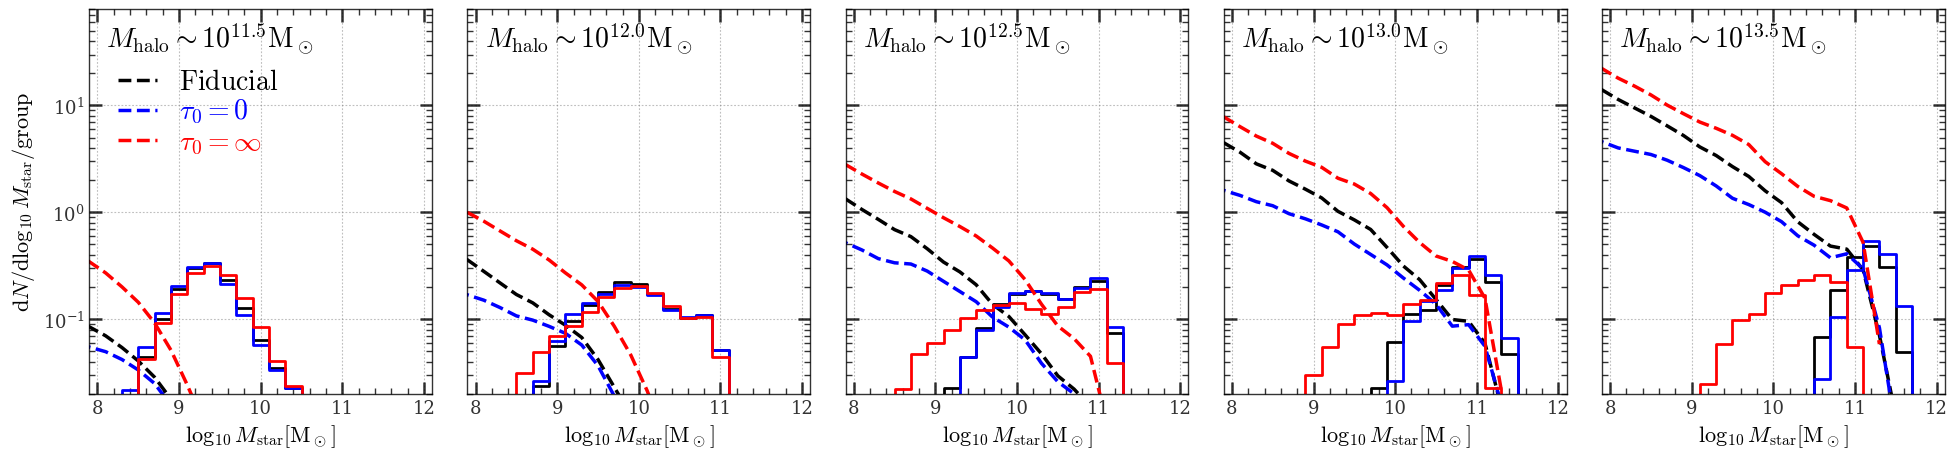

In [257]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5), squeeze=False)
colors = 'k b r'.split()
mhalo_bins = np.linspace(11.5, 13.5, 5)
mstar_edges = np.linspace(7, 12, 26)
mstar_mids = (mstar_edges[:-1] + mstar_edges[1:]) / 2
labels = [r'$\rm Fiducial$', r'$\tau_0=0$', r'$\tau_0=\infty$']
for igal, gal in enumerate([gals_base, gals_zero, gals_inf]):
    mstar = (gal['mstar'].values)
    mhalo = (gal['mhalo'].values)
    ifcen = (gal['is_central'].values == 1)
    for imhalo, mhalobin in enumerate(mhalo_bins):
        mask = (np.abs(mhalo - mhalobin) < 0.2)
        ax = axes[0, imhalo]

        ngrp = np.count_nonzero(ifcen & mask)
        cmf_cen = binned_statistic_overlap(mstar[mask & ifcen], np.ones(np.count_nonzero(mask & ifcen)), mstar_mids, 0.3, 1, func=np.sum) / ngrp
        cmf_all = binned_statistic_overlap(mstar[mask], np.ones(np.count_nonzero(mask)), mstar_mids, 0.3, 1, func=np.sum) / ngrp
        cmf_sat = binned_statistic_overlap(mstar[mask & (~ifcen)], np.ones(np.count_nonzero(mask & (~ifcen))), mstar_mids, 0.3, 1, func=np.sum) / ngrp
        cmf_cen = np.where(np.isfinite(cmf_cen), cmf_cen, 0)
        ax.plot(mstar_mids, cmf_sat, color=colors[igal], ls='--', label=labels[igal])
        ax.step(mstar_mids, cmf_cen, c=to_rgba(colors[igal], 1), lw=2)
        if igal == 0:
            ax.annotate(r"$M_{\rm halo}\sim 10^{%.1f}\rm M_\odot$" % mhalobin, (0.05, 0.9), xycoords="axes fraction")

axes[0, 0].legend(loc=(0.04, 0.6), labelcolor=colors, fontsize=20)
for ax in fig.get_axes():
    ax.set_yscale('log')
    ax.axis([7.9, 12.1, 2e-2, 8e1])
    ax.set_xlabel(r"$\log_{10}M_{\rm star}[{\rm M_\odot}]$")
    ax.set_ylabel(r"${\rm d}N/{\rm d}\log_{10}M_{\rm star}/{\rm group}$")
    ax.label_outer()
fig.tight_layout()
fig.savefig('./result/galform_dynfric/cmf.pdf')

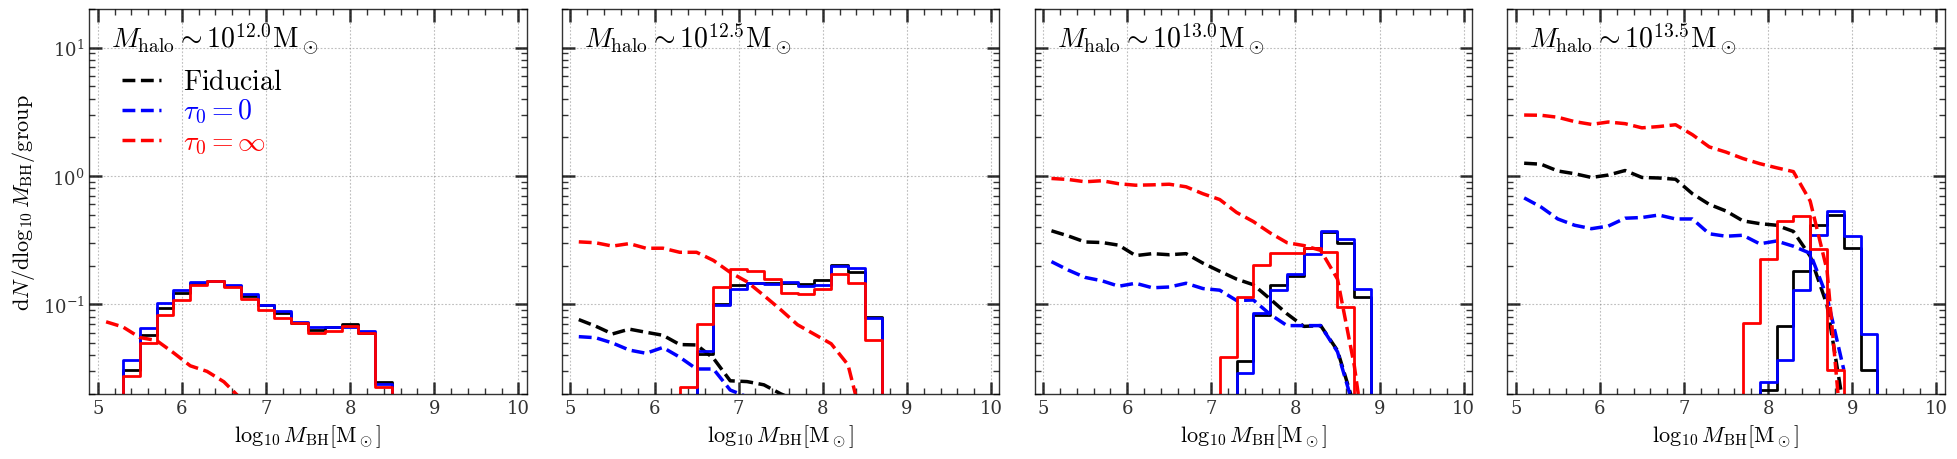

In [258]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), squeeze=False)
colors = 'k b r'.split()
mhalo_bins = np.linspace(12, 13.5, 4)
mbh_edges = np.linspace(5, 10, 26)
mbh_mids = (mbh_edges[:-1] + mbh_edges[1:]) / 2
labels = [r'$\rm Fiducial$', r'$\tau_0=0$', r'$\tau_0=\infty$']
for igal, gal in enumerate([gals_base, gals_zero, gals_inf]):
    mbh = (gal['mbh'].values)
    mhalo = (gal['mhalo'].values)
    ifcen = (gal['is_central'].values == 1)
    for imhalo, mhalobin in enumerate(mhalo_bins):
        mask = (np.abs(mhalo - mhalobin) < 0.2)
        ax = axes[0, imhalo]

        ngrp = np.count_nonzero(ifcen & mask)
        cmf_cen = binned_statistic_overlap(mbh[mask & ifcen], np.ones(np.count_nonzero(mask & ifcen)), mbh_mids, 0.3, 1, func=np.sum) / ngrp
        cmf_all = binned_statistic_overlap(mbh[mask], np.ones(np.count_nonzero(mask)), mbh_mids, 0.3, 1, func=np.sum) / ngrp
        cmf_sat = binned_statistic_overlap(mbh[mask & (~ifcen)], np.ones(np.count_nonzero(mask & (~ifcen))), mbh_mids, 0.3, 1, func=np.sum) / ngrp
        cmf_cen = np.where(np.isfinite(cmf_cen), cmf_cen, 0)
        ax.plot(mbh_mids, cmf_sat, color=colors[igal], ls='--', label=labels[igal])
        ax.step(mbh_mids, cmf_cen, c=to_rgba(colors[igal], 1), lw=2)
        if igal == 0:
            ax.annotate(r"$M_{\rm halo}\sim 10^{%.1f}\rm M_\odot$" % mhalobin, (0.05, 0.9), xycoords="axes fraction")

axes[0, 0].legend(loc=(0.04, 0.6), labelcolor=colors, fontsize=20)
for ax in fig.get_axes():
    ax.set_yscale('log')
    ax.axis([4.9, 10.1, 2e-2, 2e1])
    ax.set_xlabel(r"$\log_{10}M_{\rm BH}[{\rm M_\odot}]$")
    ax.set_ylabel(r"${\rm d}N/{\rm d}\log_{10}M_{\rm BH}/{\rm group}$")
    ax.label_outer()
fig.tight_layout()
fig.savefig('./result/galform_dynfric/cbhmf.pdf')

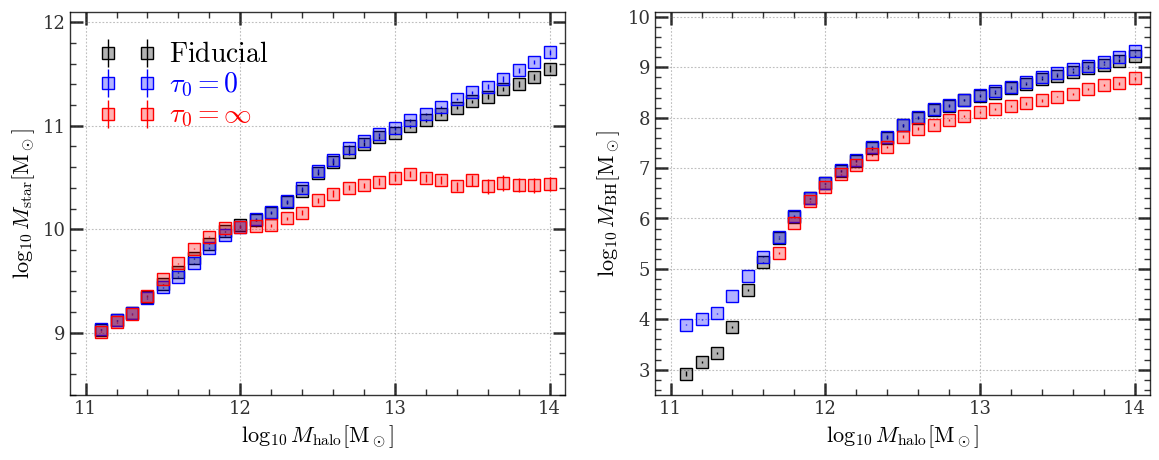

In [259]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)
eb_kw = dict(ls='', lw=1, capthick=1, capsize=0, marker='s', ms=8, mew=1)
colors = 'k b r'.split()
mhalo_bins = np.linspace(11, 14, 31)
labels = [r'$\rm Fiducial$', r'$\tau_0=0$', r'$\tau_0=\infty$']
for igal, gal in enumerate([gals_base, gals_zero, gals_inf]):
    mbh = (gal['mbh'].values)
    mstar = (gal['mstar'].values)
    mhalo = (gal['mhalo'].values)
    ifcen = (gal['is_central'].values == 1)
    for iprop, prop in enumerate([mstar, mbh]):
        ax = axes[0, iprop]
        ys, es = binned_statistic_overlap(mhalo[ifcen], prop[ifcen], mhalo_bins, 0.3, 10, func=np.nanmedian, bts=True)
        ax.errorbar(mhalo_bins, ys, es, c=colors[igal], mec=colors[igal], mfc=to_rgba(colors[igal], 0.3), label=labels[igal], **eb_kw)
        
ax = axes[0, 0]   
ax.set_ylim(8.4, 12.1)
ax.set_yticks([9, 10, 11, 12])
ax.set_ylabel(r"$\log_{10}M_{\rm star}[{\rm M_\odot}]$")
    
ax = axes[0, 1]
ax.set_ylim(2.5, 10.1)
ax.set_ylabel(r"$\log_{10}M_{\rm BH}[{\rm M_\odot}]$")

axes[0, 0].legend(loc='upper left', labelcolor=colors)
for ax in fig.get_axes():
    ax.set_xlabel(r"$\log_{10}M_{\rm halo}[{\rm M_\odot}]$")
    ax.set_xlim(10.9, 14.1)
    ax.set_xticks([11, 12, 13, 14])
fig.tight_layout()
fig.savefig('./result/galform_dynfric/cen_mbh_mstar_mhalo.pdf')

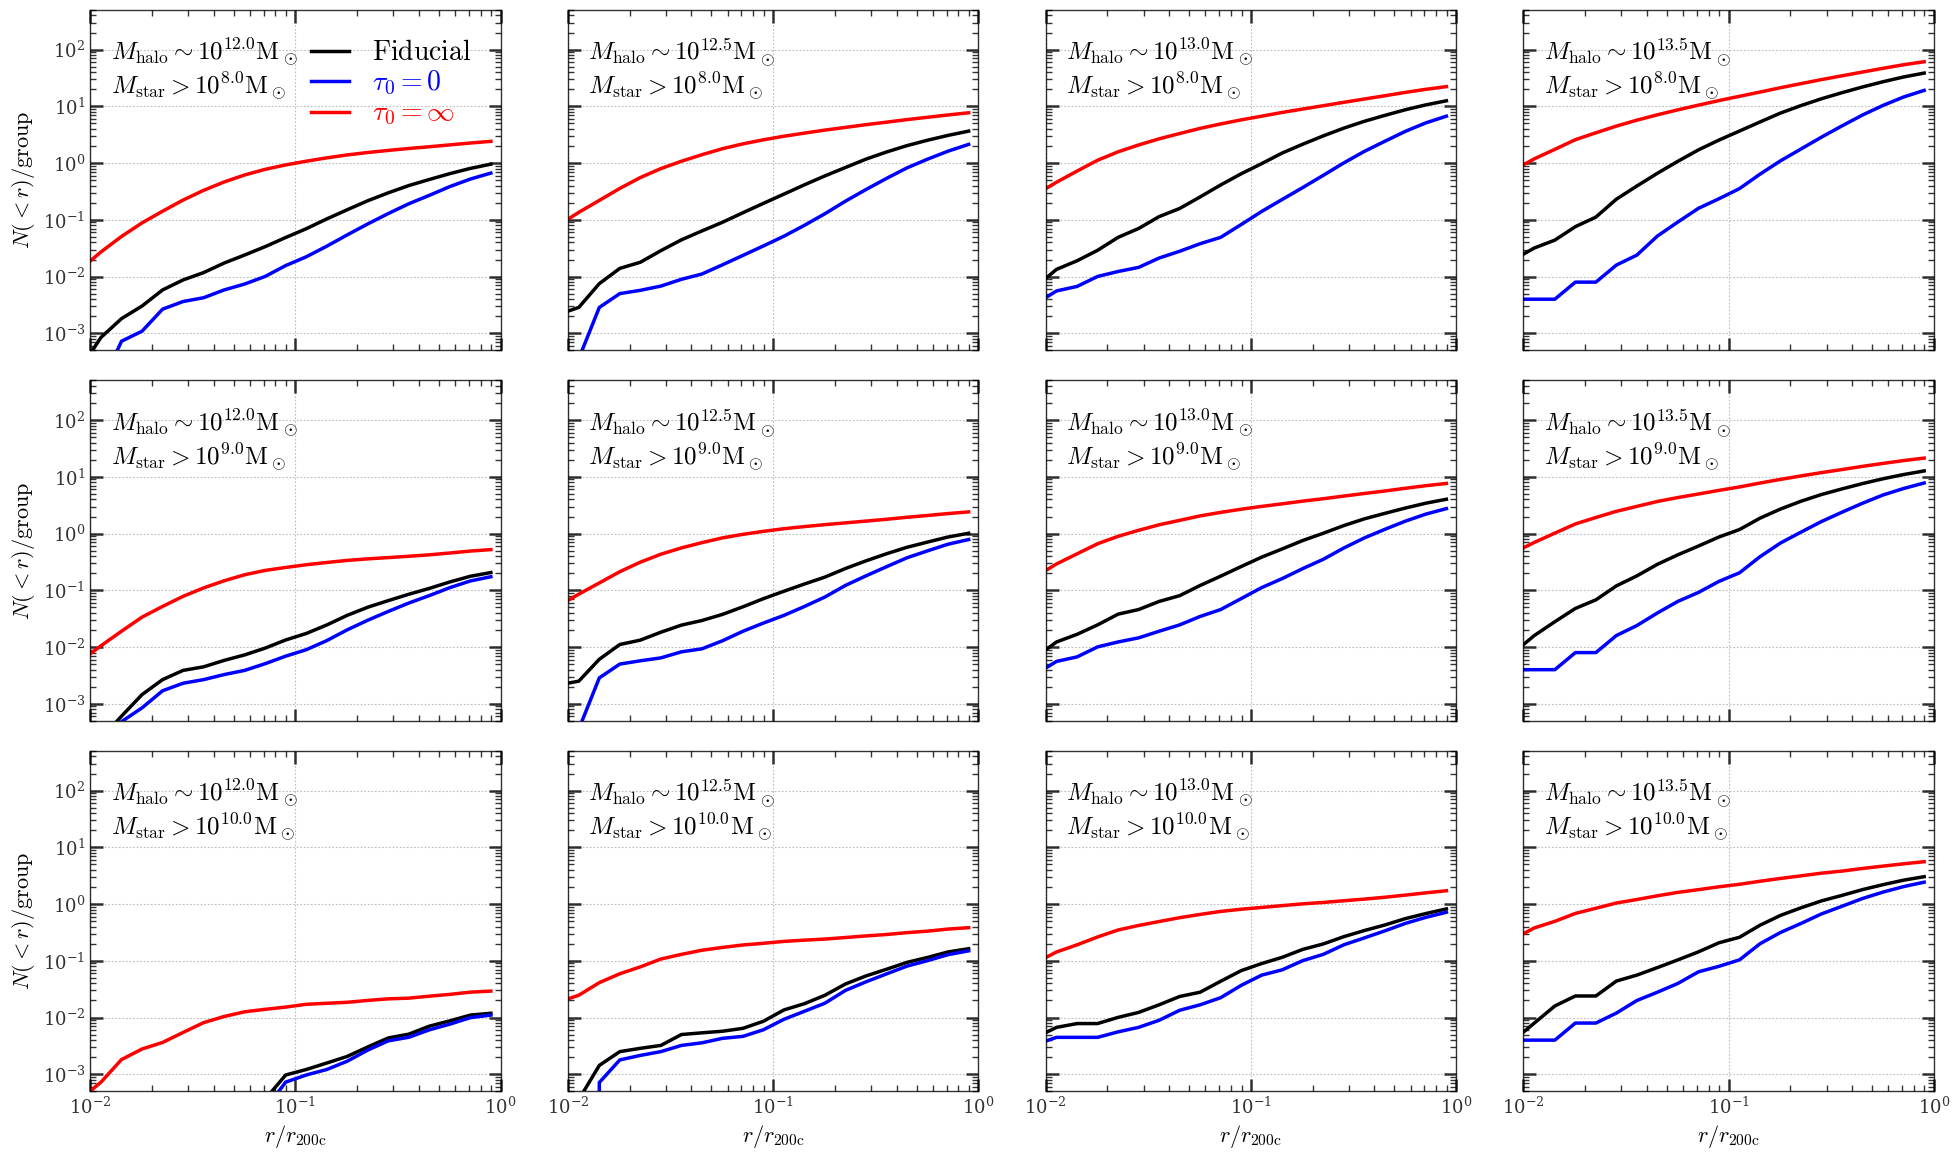

In [267]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12), squeeze=False)
colors = 'k b r'.split()
mhalo_bins = np.linspace(12, 13.5, 4)
rnorm_edges = np.logspace(-3, 0, 31)
rnorm_mids = (rnorm_edges[:-1] + rnorm_edges[1:]) / 2
labels = [r'$\rm Fiducial$', r'$\tau_0=0$', r'$\tau_0=\infty$']

mstarlim = 8
for igal, gal in enumerate([gals_base, gals_zero, gals_inf]):
    mstar = (gal['mstar'].values)
    mhalo = (gal['mhalo'].values)
    ifcen = (gal['is_central'].values == 1)
    drnorm = gal['dr_norm'].values
    for imstarlim, mstarlim in enumerate([8, 9, 10]):
        for imhalo, mhalobin in enumerate(mhalo_bins):
            mask = (np.abs(mhalo - mhalobin) < 0.2)
            ax = axes[imstarlim, imhalo]
    
            ngrp = np.count_nonzero(ifcen & mask)
            hist_sat = np.cumsum(np.histogram(drnorm[mask & (~ifcen) & (mstar > mstarlim)], rnorm_edges)[0]) / ngrp
            ax.plot(rnorm_mids, hist_sat, color=colors[igal], ls='-', label=labels[igal])
            if igal == 0:
                ax.annotate(r"$M_{\rm halo}\sim 10^{%.1f}{\rm M_\odot}$" % mhalobin, (0.05, 0.85), xycoords="axes fraction", fontsize=18)
                ax.annotate(r"$M_{\rm star}> 10^{%.1f}{\rm M_\odot}$" % mstarlim, (0.05, 0.75), xycoords="axes fraction", fontsize=18)

axes[0, 0].legend(loc='upper right', labelcolor=colors, fontsize=20)

for ax in fig.get_axes():
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.axis([1e-2, 1e0, 5e-4, 5e2])
    ax.set_xlabel(r"$r/r_{\rm 200c}$")
    ax.set_ylabel(r"$N(<r)/{\rm group}$")
    ax.label_outer()
fig.tight_layout()
# fig.savefig('./result/galform_dynfric/radial_profile.pdf')

# Dependence on subvolume

In [6]:
import numpy as np
from halotools.mock_observables import npairs_3d, marked_tpcf

def load_gals(file, snap, ivols=None):
    gals = []
    ivols = np.arange(10) if ivols is None else ivols
    for ivol in ivols:
        gal = pd.DataFrame()
        with h5py.File(file % (snap, ivol), 'r') as f:
            logzsolar = np.log10(0.017)
            logh = np.log10(0.7)
            g = f['Output001']
            mask = (g['mhhalo'][()] > 1e11)
            gal["igrp"] = ((g['mhhalo'][()] * g['vhhalo'][()]).astype(int))[mask]
            gal['is_central'] = g['is_central'][()][mask]
            gal['xgal'] = g['xgal'][()][mask]
            gal['ygal'] = g['ygal'][()][mask]
            gal['zgal'] = g['zgal'][()][mask]
            gal["mstar"] = (np.log10(g['mstars_bulge'][()] + g['mstars_disk'][()] + 1e-3))[mask] - logh
            gal["mhalo"] = (np.log10(g['mhhalo'][()] + 1e-3))[mask] - logh
        gals.append(gal)
    gals = pd.concat(gals)
    ngrp = len(np.unique(gals['igrp'].values))
    map_igrp = dict(zip(np.unique(gals['igrp'].values), np.arange(ngrp)))
    gals['igrp'] = np.array([map_igrp[i] for i in gals['igrp'].values])

    cen = gals[gals['is_central'] == 1]
    pos_cen = np.zeros((len(cen), 3))
    pos_cen[cen['igrp'].values, 0] = cen['xgal'].values
    pos_cen[cen['igrp'].values, 1] = cen['ygal'].values
    pos_cen[cen['igrp'].values, 2] = cen['zgal'].values

    dx = gals['xgal'].values - pos_cen[gals['igrp'].values, 0]
    dy = gals['ygal'].values - pos_cen[gals['igrp'].values, 1]
    dz = gals['zgal'].values - pos_cen[gals['igrp'].values, 2]

    L = 542.16
    dx = np.where(dx > L / 2, dx - L, dx)
    dx = np.where(dx < - L / 2, dx + L, dx)
    dy = np.where(dy > L / 2, dy - L, dy)
    dy = np.where(dy < - L / 2, dy + L, dy)
    dz = np.where(dz > L / 2, dz - L, dz)
    dz = np.where(dz < - L / 2, dz + L, dz)
    dr = np.sqrt(dx * dx + dy * dy + dz * dz)
    gals['dr'] = dr
    gals['rhalo'] = halo_mass_to_halo_radius(10**gals['mhalo'], cosmo, 0, "200c")
    gals['dr_norm'] = gals['dr']/ gals['rhalo']
    gals = gals[gals['dr_norm'] < 1]
    return gals


def xi_unbiased_from_group_downsample_marked(
    x, y, z, gid, f_group, rbins, period,
    num_threads=1,
):

    sample = np.vstack((x, y, z)).T

    # DD_all_obs should be length len(rbins)-1
    DD_all_obs = np.diff(npairs_3d(sample, sample, rbins, period=L))
    
    # Same-group fraction M_eq = DD_same_obs / DD_all_obs
    _, gid_compact = np.unique(gid, return_inverse=True)
    marks = np.vstack((gid_compact.astype(float), np.ones_like(gid_compact, dtype=float))).T

    M_eq = marked_tpcf(
        sample, rbins,
        marks1=marks,
        period=period,
        normalize_by="number_counts",
        weight_func_id=3,
        num_threads=num_threads,
    )

    DD_same_obs = M_eq * DD_all_obs

    inv_f  = 1.0 / f_group
    inv_f2 = 1.0 / (f_group * f_group)
    DD_full_hat = inv_f2 * DD_all_obs + (inv_f - inv_f2) * DD_same_obs
    

    # ---- Halotools-style Landy–Szalay using analytic DR, RR in a periodic box ----
    # Use the same raw-count convention as halotools _TP_estimator.
    Vbox = period**3
    N_obs = sample.shape[0]
    N_full = N_obs / f_group
    N_R = N_full

    shell_vol = np.diff((4.0 * np.pi / 3.0) * rbins**3)

    # Choose a (deterministic) random catalogue size; analytic expectations remove noise anyway.
    # Setting NR = N_full is convenient and matches typical halotools usage.
    DD = DD_full_hat / N_full**2
    RR = N_R * N_R / Vbox * shell_vol / N_R**2
    DR = N_full * N_R / Vbox * shell_vol / (N_full * N_R)
    xi_full = (DD - 2 * DR + RR) / RR
    return xi_full


In [7]:
from halotools.mock_observables import tpcf

nvols = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
rbins = np.logspace(-1, 1.5, 21)
rmids = (rbins[:-1] + rbins[1:]) / 2
L = 542.16
mstarlim = 9

snap = 271
gals_list = []
galdir = "/cosma5/data/durham/dc-hick2/Galform_Out/L800/gp14/"
for nvol in nvols:
    print(nvol)
    gals_list.append(load_gals(galdir + 'iz%d/ivol%d/galaxies.hdf5', snap, np.arange(nvol)))

2
4
8
16
32
64
128
256
512
1024


In [8]:
tpcf_list = []
for igal, gals in enumerate(gals_list):
    print(igal)
    mask = gals['mstar'] > mstarlim
    tpcf_tmp = tpcf(gals[mask]['xgal ygal zgal'.split()].values, rbins, period=L, estimator='Landy-Szalay', num_threads=4)
    tpcf_list.append(tpcf_tmp)

0
1
2
3
4
5
6
7
8
9


In [57]:
tpcfc_list = []
for igal, gals in enumerate(gals_list[:8]):
    print(igal)
    mask = gals['mstar'] > mstarlim
    f = 2**(igal + 1) / 1024
    tpcfc_tmp = xi_unbiased_from_group_downsample_marked(*gals[mask]['xgal ygal zgal'.split()].values.T, gals[mask]['igrp'].values, f, rbins=rbins, period=L, num_threads=4)
    tpcfc_list.append(tpcfc_tmp)

0
1
2
3
4
5
6
7


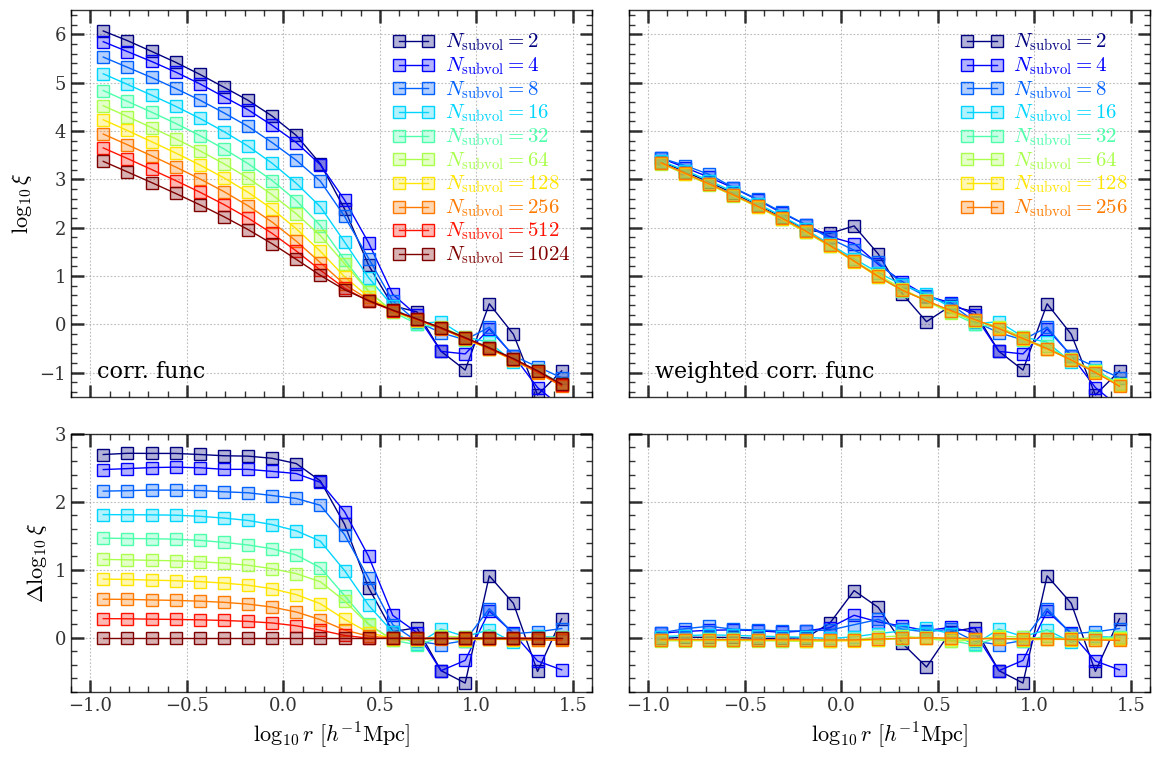

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False, gridspec_kw={'height_ratios': [3, 2]})
eb_kw = dict(ls='-', lw=1, capthick=1, capsize=0, marker='s', ms=8, mew=1)

cmap = matplotlib.colormaps["jet"]
colors = cmap(np.linspace(0, 1, len(nvols)))

for iv, v in enumerate(tpcf_list):
    ax = axes[0, 0]
    ax.errorbar(np.log10(rmids), np.log10(v), color=colors[iv], mfc=to_rgba(colors[iv], 0.3), mec=colors[iv], label=r"$N_{\rm subvol}=%d$" % nvols[iv], **eb_kw)
    ax = axes[1, 0]
    ax.errorbar(np.log10(rmids), np.log10(v / tpcf_list[-1]), color=colors[iv], mfc=to_rgba(colors[iv], 0.3), mec=colors[iv], label=r"$N_{\rm subvol}=%d$" % nvols[iv], **eb_kw)
    
for iv, v in enumerate(tpcfc_list):
    ax = axes[0, 1]
    ax.errorbar(np.log10(rmids), np.log10(v), color=colors[iv], mfc=to_rgba(colors[iv], 0.3), mec=colors[iv], label=r"$N_{\rm subvol}=%d$" % nvols[iv], **eb_kw)
    ax = axes[1, 1]
    ax.errorbar(np.log10(rmids), np.log10(v / tpcf_list[-1]), color=colors[iv], mfc=to_rgba(colors[iv], 0.3), mec=colors[iv], label=r"$N_{\rm subvol}=%d$" % nvols[iv], **eb_kw)

axes[0, 0].legend(loc='upper right', labelcolor=colors, fontsize=15)
axes[0, 1].legend(loc='upper right', labelcolor=colors, fontsize=15)
axes[0, 0].annotate(r"corr. func", (0.05, 0.05), xycoords="axes fraction", fontsize=16)
axes[0, 1].annotate(r"weighted corr. func", (0.05, 0.05), xycoords="axes fraction", fontsize=16)
for ax in axes[0, :]:
    ax.set_ylim(-1.5, 6.5)
    ax.set_ylabel(r"$\log_{10}\xi$")
for ax in axes[1, :]:
    ax.set_ylim(-0.8, 1.1)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_ylabel(r"$\Delta\log_{10}\xi$")
for ax in fig.get_axes():
    ax.set_xlim(-1.1, 1.6)
    ax.set_xlabel(r"$\log_{10}r~[h^{-1}{\rm Mpc}]$")
    ax.label_outer()
fig.tight_layout()
fig.savefig('./result/galform_dynfric/corr_func_convergence.pdf')

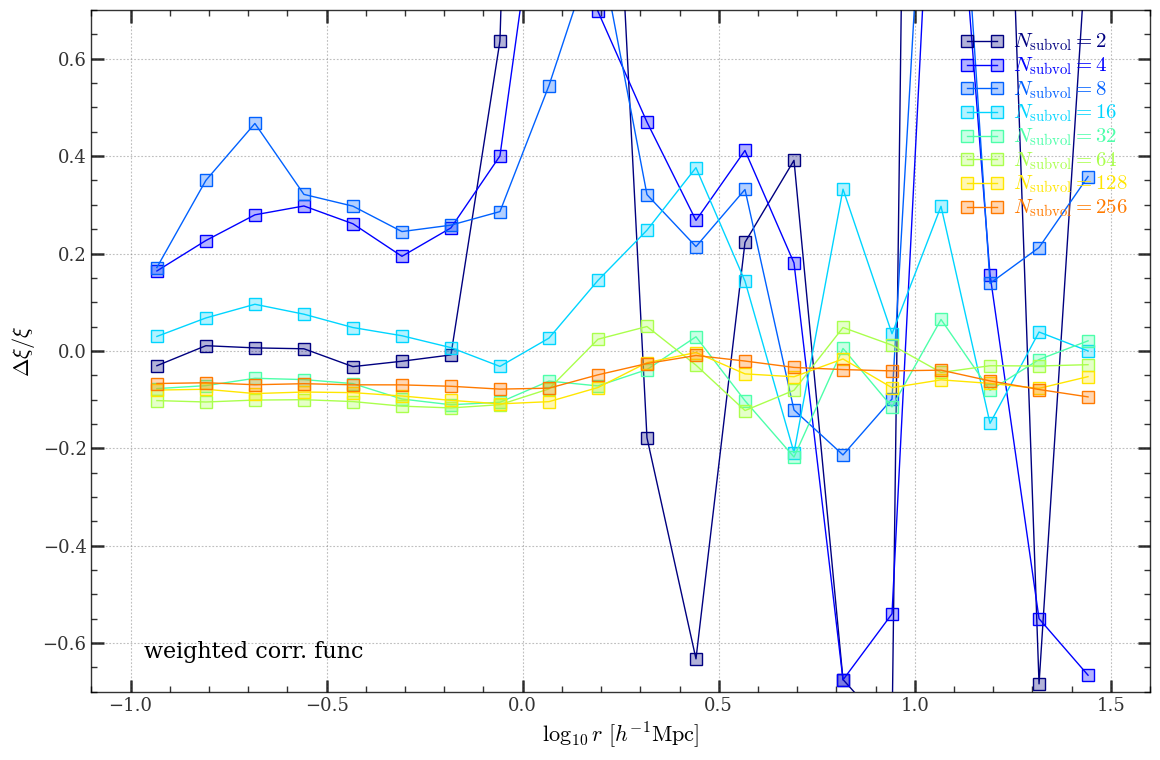

In [90]:
fig, axes = plt.subplots(1, 1, figsize=(12, 8), squeeze=False)
eb_kw = dict(ls='-', lw=1, capthick=1, capsize=0, marker='s', ms=8, mew=1)

cmap = matplotlib.colormaps["jet"]
colors = cmap(np.linspace(0, 1, len(nvols)))
    
for iv, v in enumerate(tpcfc_list):
    ax = axes[0, 0]
    ax.errorbar(np.log10(rmids), (v - tpcf_list[-1]) / tpcf_list[-1], color=colors[iv], mfc=to_rgba(colors[iv], 0.3), mec=colors[iv], label=r"$N_{\rm subvol}=%d$" % nvols[iv], **eb_kw)

axes[0, 0].legend(loc='upper right', labelcolor=colors, fontsize=15)
axes[0, 0].annotate(r"weighted corr. func", (0.05, 0.05), xycoords="axes fraction", fontsize=16)
for ax in fig.get_axes():
    ax.set_xlim(-1.1, 1.6)
    ax.set_xlabel(r"$\log_{10}r~[h^{-1}{\rm Mpc}]$")
    ax.set_ylim(-0.7, 0.7)
    ax.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
    ax.set_ylabel(r"$\Delta\xi/\xi$")
    ax.label_outer()
fig.tight_layout()
# fig.savefig('./result/galform_dynfric/corr_func_convergence_2.pdf')

# MC tree building

## Simple version

## Fast version

In [119]:
import numpy as np

# assuming the code you pasted is in the same file / already executed in the session
# (i.e. build_parkinson08_tree_fast and Parkinson08Params are in scope)



# ----- single tree -----
M0 = 1e12      # Msun/h (match your Colossus mass convention)
z0 = 0.0
zmax = 4.0
Mres = 1e9
seed = 42

mass, z, first_prog, desc = build_parkinson08_tree_fast(
    M0=M0,
    z0=z0,
    zmax=zmax,
    Mres=Mres,
    seed=seed,
    cosmo_name="planck15",
    params=params,
    # table coverage (adjust if you change M0/Mres a lot)
    logM_min=np.log(1e8),
    logM_max=np.log(1e16),
    nM=4096,
    zmax_table=6.0,
    nz=4096,
    max_nodes=300000,
)

print("N haloes:", len(mass))
print("root:", mass[0], z[0], "desc=", desc[0], "first_prog=", first_prog[0])

# main-branch history (follow first progenitors)
i = 0
main_ids = [i]
while first_prog[i] != -1:
    i = int(first_prog[i])
    main_ids.append(i)

main_ids = np.array(main_ids, dtype=int)
print("main branch length:", len(main_ids))
print("main branch last z:", z[main_ids[-1]], "mass:", mass[main_ids[-1]])

# sanity: descendant pointer is consistent along main branch
ok = True
for k in range(1, len(main_ids)):
    if desc[main_ids[k]] != main_ids[k-1]:
        ok = False
        break
print("descendant pointers consistent on main branch:", ok)



N haloes: 2286
root: 1000000000000.0 0.0 desc= -1 first_prog= 1
main branch length: 1028
main branch last z: 3.9990752679464157 mass: 7847139745.631586
descendant pointers consistent on main branch: True


Built 32 trees in 21.809 s
Mean time per tree: 0.6815 s


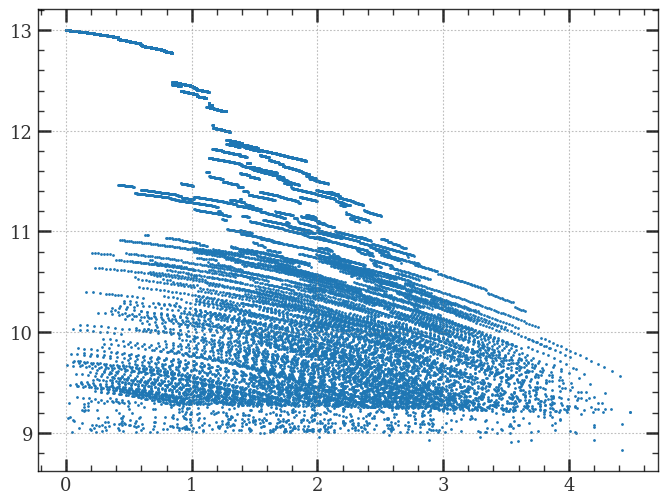

## Assign to snapshots

In [ ]:
import numpy as np

def regrid_tree_to_snapshots(
    mass: np.ndarray,
    z: np.ndarray,
    first_prog: np.ndarray,
    desc: np.ndarray,
    z_snaps: np.ndarray,
):
    """
    Regrid a single tree (mass,z,first_prog,desc) onto a predefined snapshot redshift grid.

    For each snapshot redshift z_s, for each *branch segment* connecting a halo at (z_d, M_d)
    to its progenitor at (z_p, M_p) (with z_p > z_d), we linearly interpolate M(z_s) if
    z_s lies in [z_d, z_p]. This yields exactly one "interpolated halo" per original edge per snapshot.
    Multiple progenitors can map to the same descendant snapshot halo => multiple mergers.

    Parameters
    ----------
    mass, z : (N,) arrays for original nodes.
    first_prog : (N,) int (not used here, but kept for completeness).
    desc : (N,) int, descendant index (-1 for root).
    z_snaps : (S,) snapshot redshifts (need not match node z). Can be ascending or descending.

    Returns
    -------
    snap_mass : (Nsnap_nodes,) float
    snap_z    : (Nsnap_nodes,) float
    snap_desc : (Nsnap_nodes,) int, descendant index in snapped arrays (-1 for roots at lowest z)
    snap_first_prog : (Nsnap_nodes,) int, index of most massive progenitor at next snapshot (-1 if none)
    snap_next_prog  : (Nsnap_nodes,) int, linked list for additional progenitors of the same descendant (-1 if none)
                      (this makes iterating all progenitors O(#progs) without sorting)
    snap_id_of_orig_edge : (Nsnap_nodes,) tuple-like stored as two ints (u,v) in separate arrays
                      giving the original edge that generated this snapped halo (useful for debugging)
    """
    mass = np.asarray(mass, float)
    z = np.asarray(z, float)
    desc = np.asarray(desc, np.int64)
    z_snaps = np.asarray(z_snaps, float)

    # ensure increasing z for bin logic
    if z_snaps[0] > z_snaps[-1]:
        z_snaps_inc = z_snaps[::-1]
        reversed_out = True
    else:
        z_snaps_inc = z_snaps
        reversed_out = False

    S = len(z_snaps_inc)
    zmin, zmax = z_snaps_inc[0], z_snaps_inc[-1]

    # Build list of original edges: (child=i at lower z) <- (prog=j at higher z)
    # In our tree arrays, desc[child]=parent (lower z). So edge is (parent -> child) in time-forward;
    # here we need (parent as descendant, child as progenitor) across increasing z.
    # We'll treat each pair (p=descendant, c=progenitor) with z[c] > z[p].
    edges = []
    for c in range(len(mass)):
        p = int(desc[c])
        if p < 0:
            continue
        z_p = z[p]
        z_c = z[c]
        if z_c <= z_p:
            continue
        # skip edges outside snapshot range quickly
        if z_c < zmin or z_p > zmax:
            continue
        edges.append((p, c))
    edges = np.asarray(edges, dtype=np.int64)
    if edges.size == 0:
        # nothing to map
        return (
            np.array([], float),
            np.array([], float),
            np.array([], np.int64),
            np.array([], np.int64),
            np.array([], np.int64),
            np.array([], np.int64),
            np.array([], np.int64),
        )

    # For each edge (p,c), determine which snapshot intervals it crosses.
    # We create snapped nodes at snapshot redshifts z_s that lie in (z_p, z_c] (or [z_p,z_c]—choose convention).
    # We'll use (z_p, z_c] so the descendant sits at lower snapshot and progenitor at higher snapshot.
    snap_mass = []
    snap_z = []
    snap_desc = []
    snap_edge_u = []
    snap_edge_v = []

    # Mapping: for each (snapshot index s, original node p that covers z_s), we need a unique snapped ID.
    # But the same descendant can have multiple incoming progenitors at the same snapshot; that's fine.
    # We will instead identify snapped halos by "edge instance at snapshot": (p,c,s).
    # Descendant pointer in snapped arrays will connect (p,c,s_high) -> (p,*,s_low) with same p?
    # To make a conventional tree, we create nodes at each snapshot for each original node p
    # by taking the maximum-mass interpolation among edges entering p. That’s more work.
    #
    # Here we implement a simpler, analysis-friendly format:
    #   - nodes = interpolated progenitors at each snapshot
    #   - snap_desc points to the interpolated descendant node at the immediately lower snapshot along the SAME edge.
    # Then multiple progenitors naturally share a common descendant node if their edges meet at that snapshot.
    #
    # To enable that, we need a unique snapped node for each original node i at each snapshot s.
    # We'll construct those by interpolating along the *main branch* edge for i as descendant, and
    # treat additional progenitors as separate nodes pointing to that same descendant node.
    #
    # Implementation approach:
    # 1) For each original node i, identify its "main progenitor" at higher z: the most massive child among those with desc= i.
    # 2) Build snapped nodes for each original node i at each snapshot using the segment between i and its main progenitor.
    # 3) For each additional progenitor edge into i, build snapped progenitor node at that same snapshot and link to i's snapped node.

    N = len(mass)
    # build list of children for each parent
    children = [[] for _ in range(N)]
    for c in range(N):
        p = int(desc[c])
        if p >= 0 and z[c] > z[p]:
            children[p].append(c)

    main_child = np.full(N, -1, dtype=np.int64)
    for p in range(N):
        if not children[p]:
            continue
        # choose most massive progenitor (child at higher z)
        cs = np.array(children[p], dtype=np.int64)
        main_child[p] = cs[np.argmax(mass[cs])]

    # Map (orig_node i, snapshot s) -> snapped index
    snap_index = -np.ones((N, S), dtype=np.int64)

    def _interp_linear(z0, m0, z1, m1, zs):
        # linear in z
        if z1 == z0:
            return m0
        t = (zs - z0) / (z1 - z0)
        return m0 + t * (m1 - m0)

    # Create snapped nodes for each original node i on snapshots it spans along its main edge
    for i in range(N):
        j = int(main_child[i])
        if j < 0:
            continue
        z0, m0 = z[i], mass[i]
        z1, m1 = z[j], mass[j]
        if z1 <= z0:
            continue
        # which snapshots zs in [z0, z1]?
        s_lo = np.searchsorted(z_snaps_inc, z0, side="left")
        s_hi = np.searchsorted(z_snaps_inc, z1, side="right") - 1
        if s_hi < s_lo:
            continue
        for s in range(s_lo, s_hi + 1):
            zs = z_snaps_inc[s]
            if zs < z0 or zs > z1:
                continue
            if snap_index[i, s] != -1:
                continue
            idx = len(snap_mass)
            snap_index[i, s] = idx
            snap_z.append(zs)
            snap_mass.append(float(_interp_linear(z0, m0, z1, m1, zs)))
            snap_desc.append(-1)  # fill later
            snap_edge_u.append(i)
            snap_edge_v.append(j)

    # Link snapped descendants along main edges between adjacent snapshots
    for i in range(N):
        j = int(main_child[i])
        if j < 0:
            continue
        z0, z1 = z[i], z[j]
        if z1 <= z0:
            continue
        s_lo = np.searchsorted(z_snaps_inc, z0, side="left")
        s_hi = np.searchsorted(z_snaps_inc, z1, side="right") - 1
        for s in range(s_lo + 1, s_hi + 1):
            a = snap_index[i, s]
            b = snap_index[i, s - 1]
            if a != -1 and b != -1:
                snap_desc[a] = b  # higher-z node points to lower-z node

    # Now add *non-main* progenitors as extra nodes at each snapshot where they merge into i
    # For each parent i, for each additional child k!=main_child[i],
    # create snapped nodes for k at the snapshots it spans down to the snapshot of i, and point them to i's snapped node.
    extra_nodes_parent = []  # snapped idx -> snapped parent idx for setting descendant
    for i in range(N):
        if not children[i]:
            continue
        mj = int(main_child[i])
        for k in children[i]:
            if k == mj:
                continue
            # k is a merging progenitor into i between z[i] and z[k]
            z0, m0 = z[i], mass[i]
            z1, m1 = z[k], mass[k]
            if z1 <= z0:
                continue
            s_lo = np.searchsorted(z_snaps_inc, z0, side="left")
            s_hi = np.searchsorted(z_snaps_inc, z1, side="right") - 1
            if s_hi < s_lo:
                continue
            for s in range(s_lo, s_hi + 1):
                zs = z_snaps_inc[s]
                # only keep snapshots strictly above the parent snapshot (otherwise duplicate)
                if zs < z0 or zs > z1:
                    continue
                parent_snap = snap_index[i, s]
                if parent_snap == -1:
                    # if parent doesn't exist at this snapshot (e.g. leaf), skip
                    continue
                idx = len(snap_mass)
                snap_z.append(zs)
                snap_mass.append(float(_interp_linear(z0, m0, z1, m1, zs)))
                snap_desc.append(parent_snap)  # progenitor points to parent snapped halo at same snapshot
                snap_edge_u.append(i)
                snap_edge_v.append(k)
                extra_nodes_parent.append((idx, parent_snap))

    snap_mass = np.asarray(snap_mass, float)
    snap_z = np.asarray(snap_z, float)
    snap_desc = np.asarray(snap_desc, np.int64)
    snap_edge_u = np.asarray(snap_edge_u, np.int64)
    snap_edge_v = np.asarray(snap_edge_v, np.int64)

    # Build first_progenitor / next_progenitor lists in snapped space
    nS = len(snap_mass)
    snap_first_prog = np.full(nS, -1, dtype=np.int64)
    snap_next_prog = np.full(nS, -1, dtype=np.int64)

    # Group progenitors by descendant index
    # A progenitor is any node p with snap_desc[p] >= 0
    order = np.argsort(snap_desc, kind="mergesort")
    # iterate groups
    i0 = 0
    while i0 < nS:
        d = snap_desc[order[i0]]
        if d < 0:
            i0 += 1
            continue
        i1 = i0
        while i1 < nS and snap_desc[order[i1]] == d:
            i1 += 1
        progs = order[i0:i1]
        # choose most massive as first_prog
        p0 = progs[np.argmax(snap_mass[progs])]
        snap_first_prog[d] = int(p0)
        # link others via next_prog
        others = [int(p) for p in progs if p != p0]
        cur = int(p0)
        for p in others:
            snap_next_prog[cur] = p
            cur = p
        i0 = i1

    # If input snaps were decreasing, map back (node z already stored as z_snaps_inc values, so fine)
    if reversed_out:
        # nothing structural depends on ordering; caller can sort by z if needed
        pass

    return snap_mass, snap_z, snap_desc, snap_first_prog, snap_next_prog, snap_edge_u, snap_edge_v


## With subhalo